<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Data_Clustering_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 7-8: Data Clustering and ggplot2**

In [1]:
pkgs <- c("datasets", "ggplot2", "gridExtra","grid", "factoextra",
          "NbClust","dbscan")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘polynom’, ‘rstatix’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’




In [2]:
library(datasets) # For the iris dataset (if needed)
library(ggplot2)
library(gridExtra) # For grid.arrange()
library(grid)
library(factoextra) # For the eclust() function
library(NbClust) # For cluster validation
library(dbscan)

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/


Attaching package: ‘dbscan’


The following object is masked from ‘package:stats’:

    as.dendrogram




We demonstrate clustering using the well-known iris data, which we briefly saw before. This is a simple data set that is widely used to illustrate clustering algorithms.

In [3]:
head(iris)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


## **Data Visualization**

I know a cluster when I see it!

First we’ll visualize the data. We could continue to use the plot() function that we have been using up to this point.

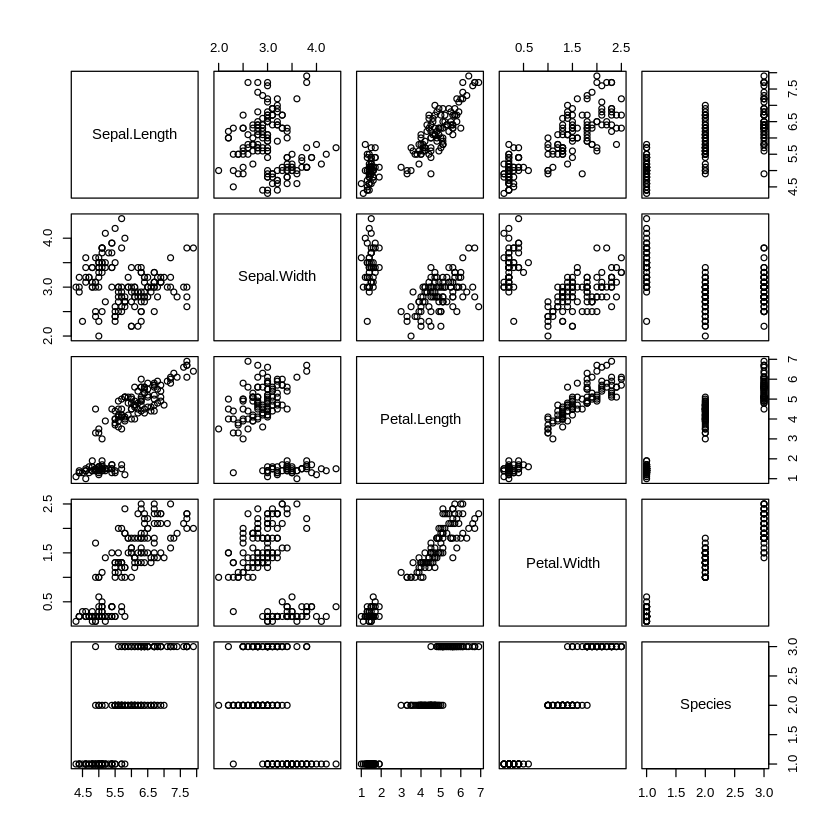

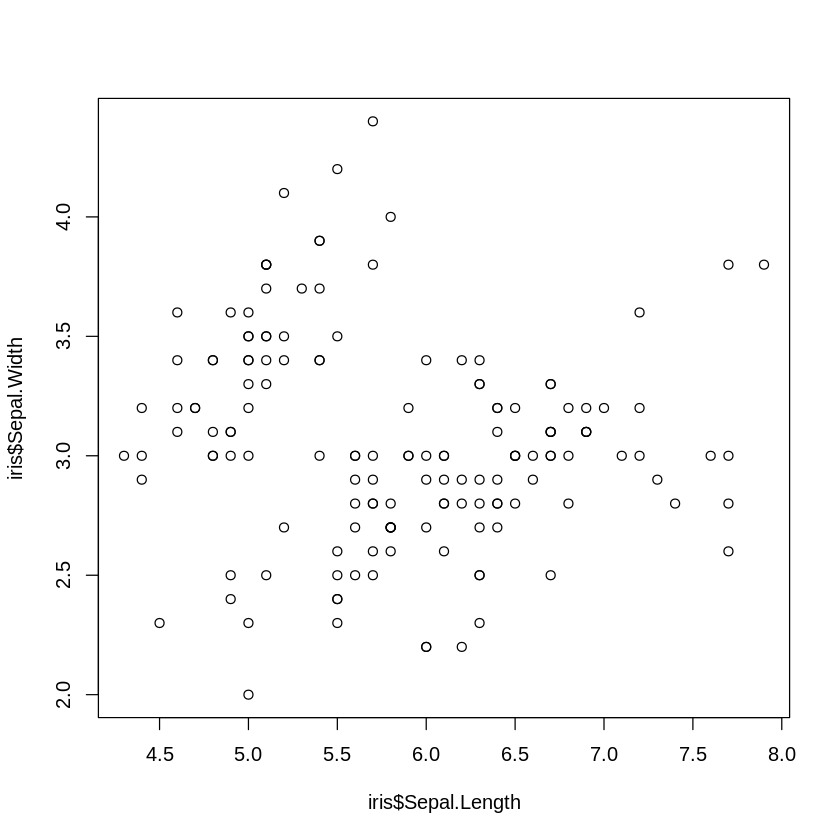

In [4]:
plot(iris)
plot(iris$Sepal.Length,iris$Sepal.Width)

This is fine, and we can do more with the plot function (like we have seen before), but let's try to use ggplot instead today.

ggplot is all about layers

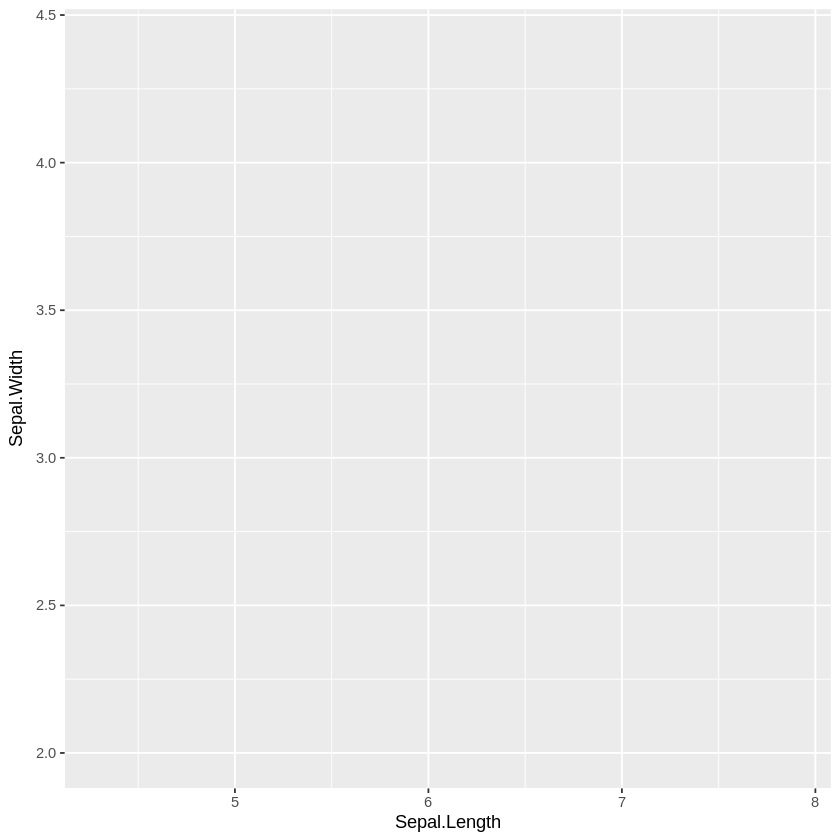

In [5]:
ggplot(iris, aes(Sepal.Length, Sepal.Width))

The ggplot function by itself just creates a blank area for us to plot on. It doesn't actually plot any data. So almost always we use it + something else

If the + something else is a scatterplot then we use geom_point()

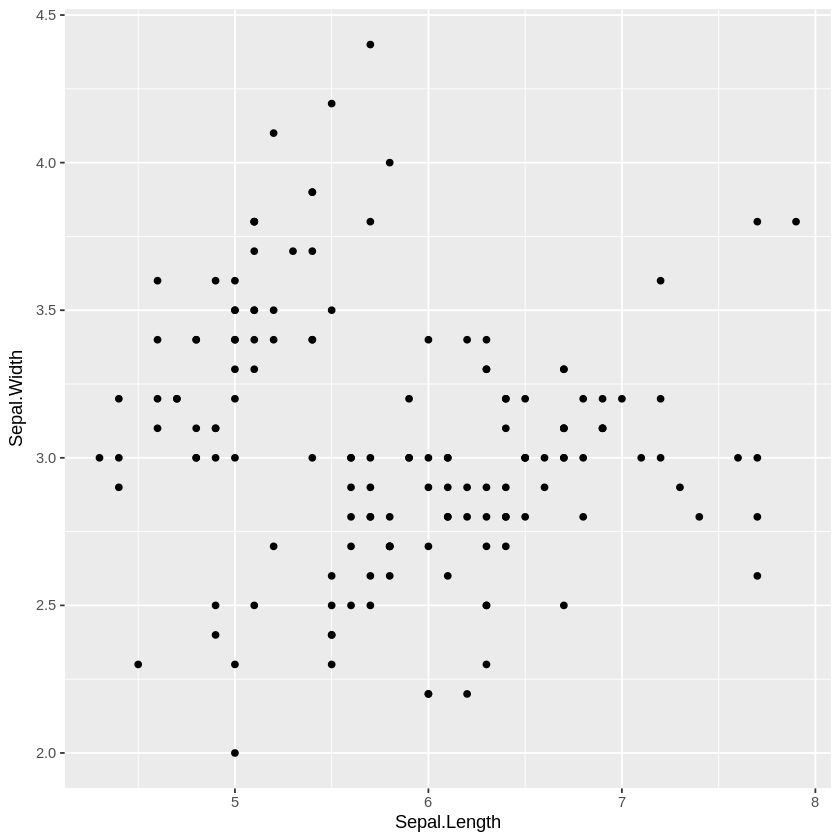

In [6]:
ggplot(iris, aes(Sepal.Length, Sepal.Width)) +
  geom_point()

aes is the aesthetic mappings used. The first is by default the x values and the second by default the y values. Things really get interesting when we add more things to the aesthetic mappings

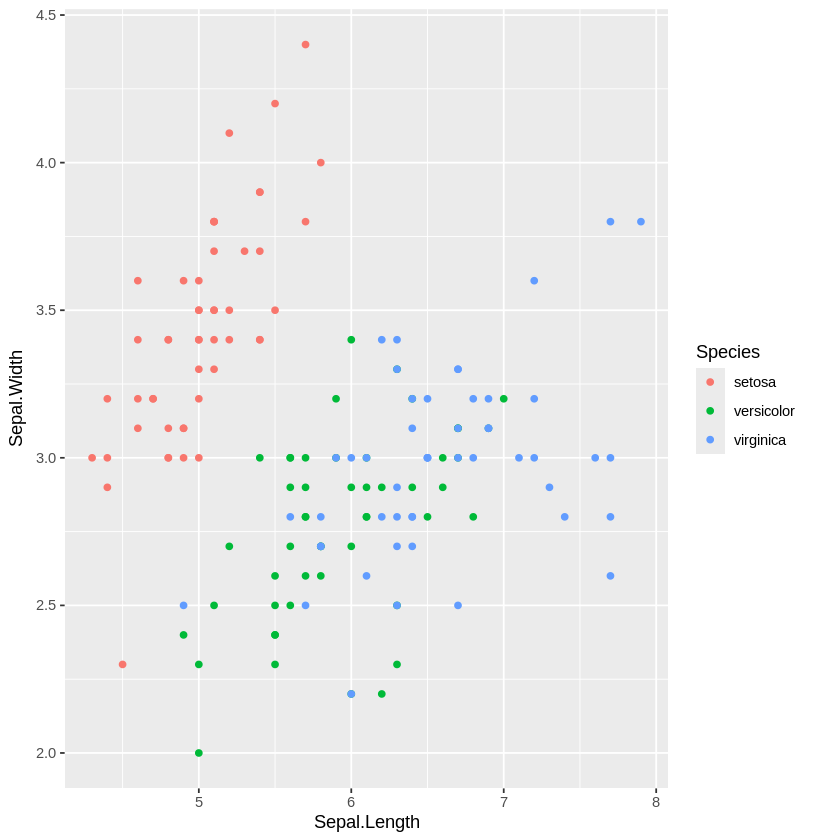

In [8]:
ggplot(iris, aes(Sepal.Length, Sepal.Width,
                 color = Species)) +
  geom_point()


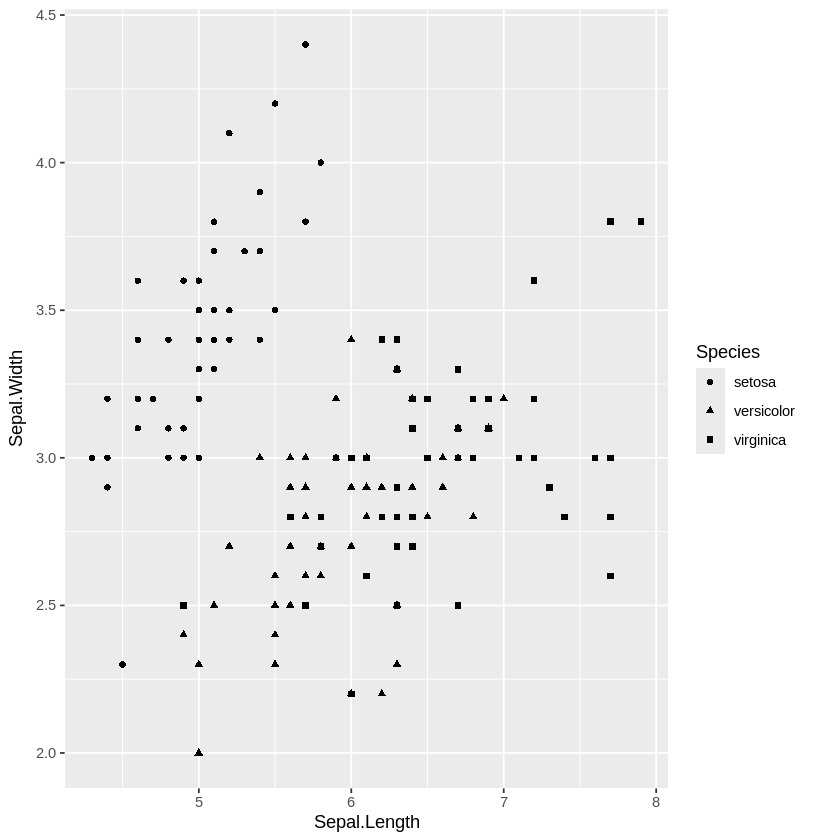

In [9]:
ggplot(iris, aes(Sepal.Length, Sepal.Width,
                 shape = Species)) +
  geom_point()

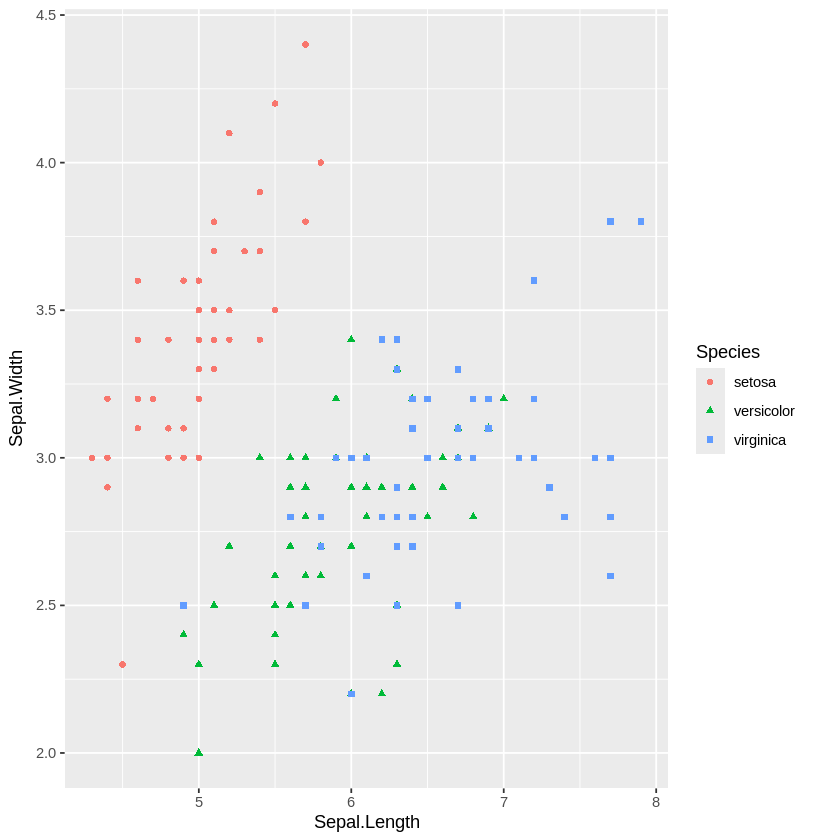

In [10]:

ggplot(iris, aes(Sepal.Length,
                 Sepal.Width,
                 color = Species,
                 shape = Species)) +
  geom_point() # Because I didn't put anything in the parenthesis, this
               # layer inherits the data and aesthetic mappings from the
               # layer above

Very often we want to plot more than one thing on the blank area, in which we can move the aesthetic mappings into each layer (here there is only one lower layer - the points)

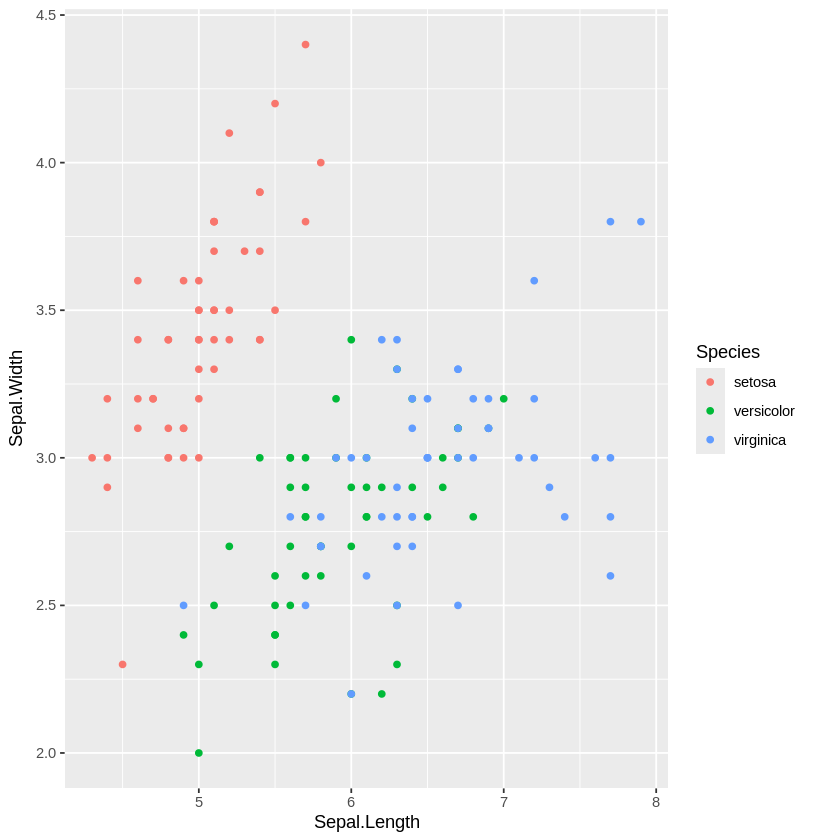

In [11]:
ggplot(iris) +
  geom_point(aes(Sepal.Length, Sepal.Width, color = Species))

Its the same as before because we only have one layer

Actually, we can get a better picture by using a different variable on the y-axis

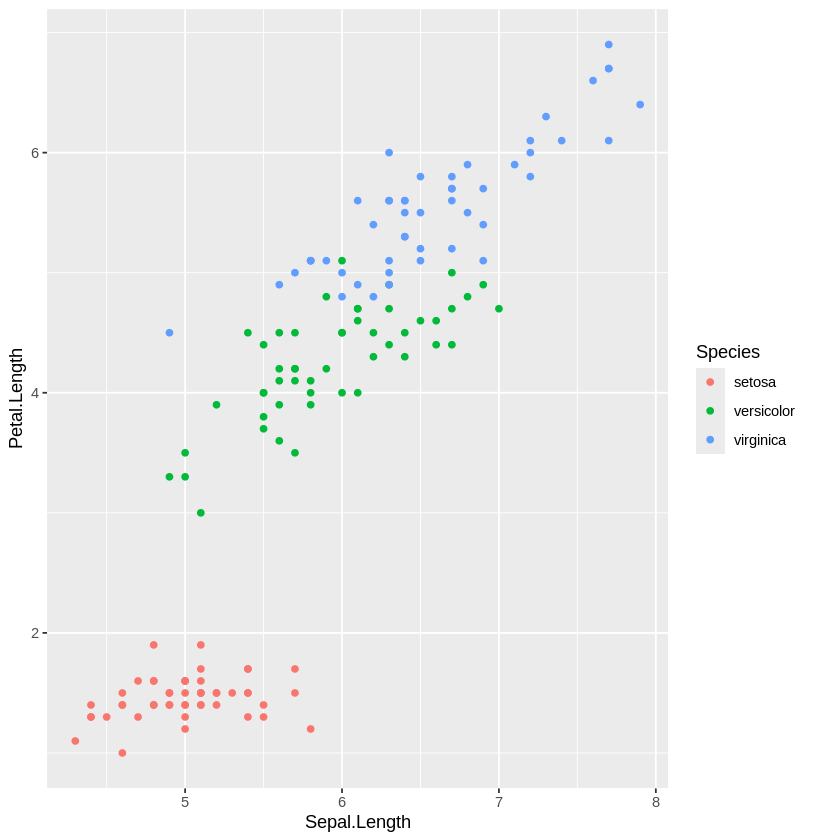

In [12]:
ggplot(iris) +
  geom_point(aes(Sepal.Length, Petal.Length,
                 color = Species))

Pretty descriptive but lacks some niceties. For example, there is no title and "Sepal.Length" while a fine variable name, doesn't look good as an axis label! Let's try again.

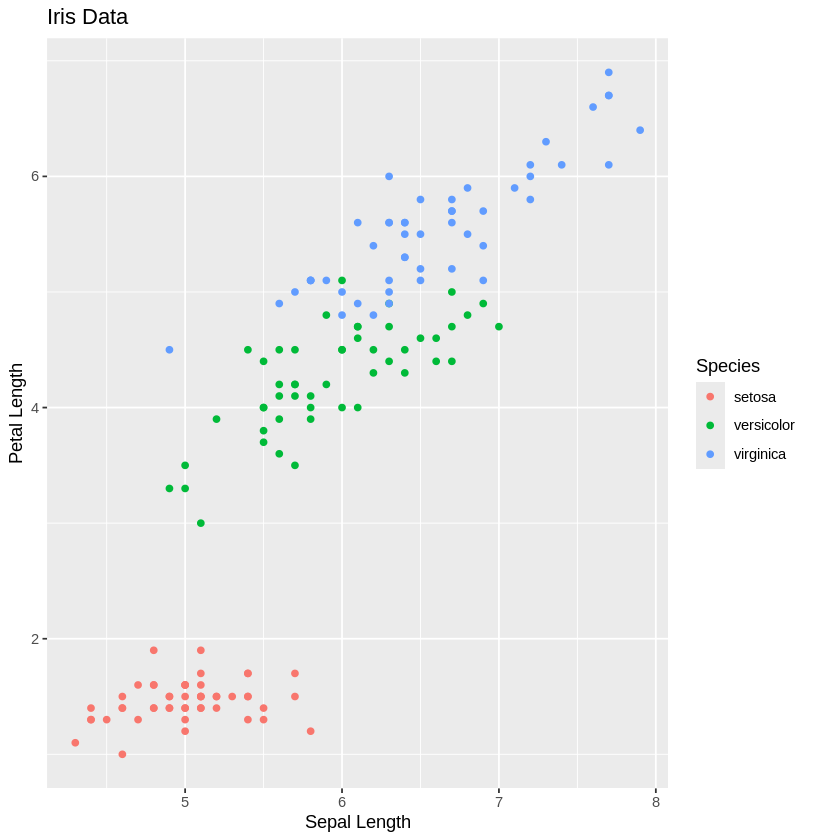

In [13]:
ggplot(iris) +
  ggtitle("Iris Data") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris,
             aes(Sepal.Length, Petal.Length,
                 color = Species))

As usual for clusters: I know clusters when I see them, but here we actually have labels (the species) so there are some true clusters. We are hoping to find 3 clusters corresponding to the 3 species of irises.

 Note that above we started out with a completely blank area (didn't even specify axis or scales). This is just to illustrate that we can - there is no particular reason to do this!

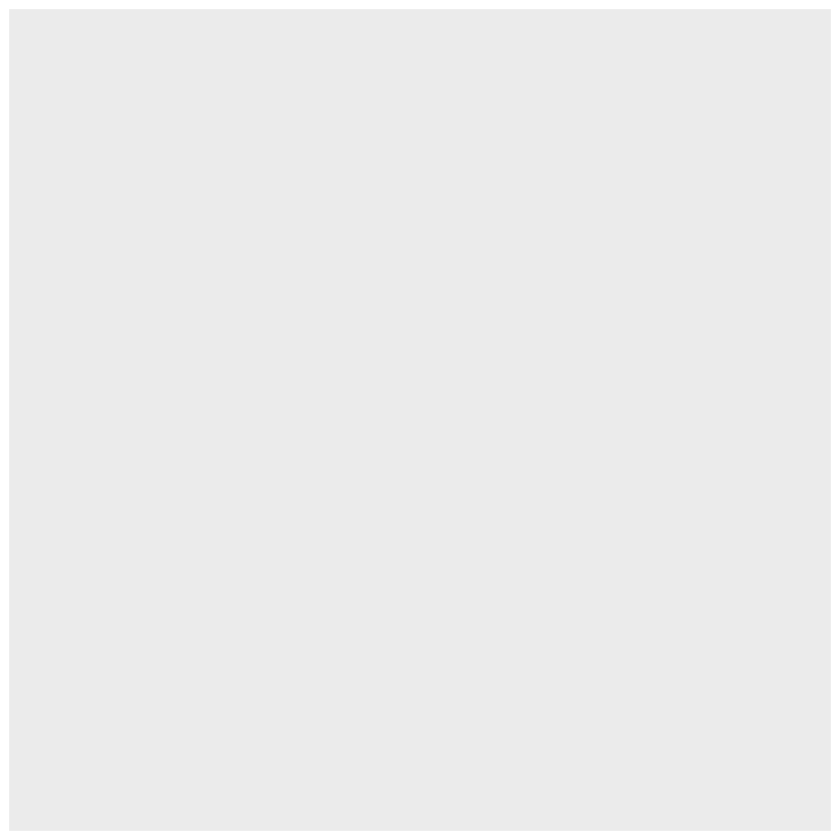

In [14]:
ggplot(iris)

But we can definitely just add one layer at a time and the data can wait.

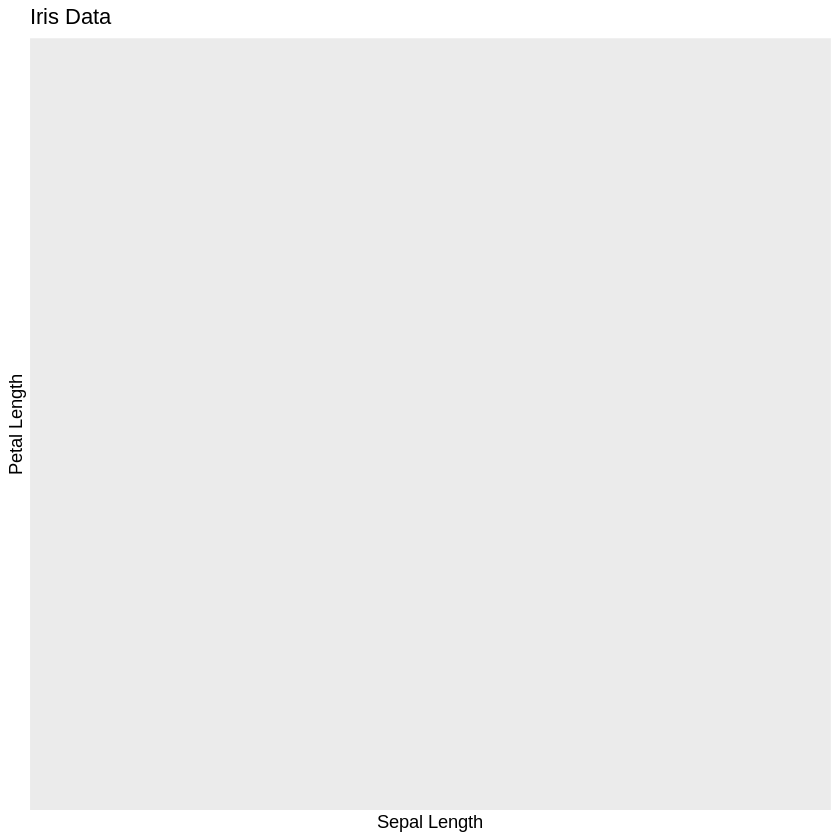

In [15]:
ggplot(iris) +
  ggtitle("Iris Data") +
  xlab("Sepal Length") +
  ylab("Petal Length")

## **K-Means Clustering**

Now on to the clustering ...

R has a built in kmeans() function. Let's create 3 clusters using only the first four variables (that is, we don't use the species):

In [16]:
set.seed(1)
clusters.km <- kmeans(iris[,1:4],centers=3)

Get the centers and size of the three clusters

In [17]:
clusters.km$centers
clusters.km$size

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
1,5.901613,2.748387,4.393548,1.433871
2,6.850000,3.073684,5.742105,2.071053
3,5.006000,3.428000,1.462000,0.246000


[1] 62 38 50

The ideal set of clusters has 50 data points in each cluster, corresponding to each species, so one cluster might be perfect, and some data points have been incorrectly moved from the third cluster to the first cluster.

Get the actual cluster assignments:

In [18]:
clusters.km$cluster

[1] 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 [38] 3 3 3 3 3 3 3 3 3 3 3 3 3 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [75] 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
[112] 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2
[149] 2 1

Could add this to the iris data, which will allow us to plot etc.

In [19]:
iris.km = cbind(iris, clusters.km$cluster)
colnames(iris.km)[6]="Cluster"
iris.km$Cluster = as.factor(iris.km$Cluster) # Must be a factor for
                                             # how we are going to
                                             # use it in ggplot later
View(iris.km)

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,Cluster
<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
5.1,3.5,1.4,0.2,setosa,3
4.9,3.0,1.4,0.2,setosa,3
4.7,3.2,1.3,0.2,setosa,3
4.6,3.1,1.5,0.2,setosa,3
5.0,3.6,1.4,0.2,setosa,3
5.4,3.9,1.7,0.4,setosa,3
4.6,3.4,1.4,0.3,setosa,3
5.0,3.4,1.5,0.2,setosa,3
4.4,2.9,1.4,0.2,setosa,3


Can now plot the species and cluster assignments in two different layers. This is the first time we've attempted two data layers!

First layer is large circles with the cluster assignments and the second layer is small triangles with the species (layers can also be different types of plotting, rather than two scatter plots).

This is also the first time we add a subtitle!

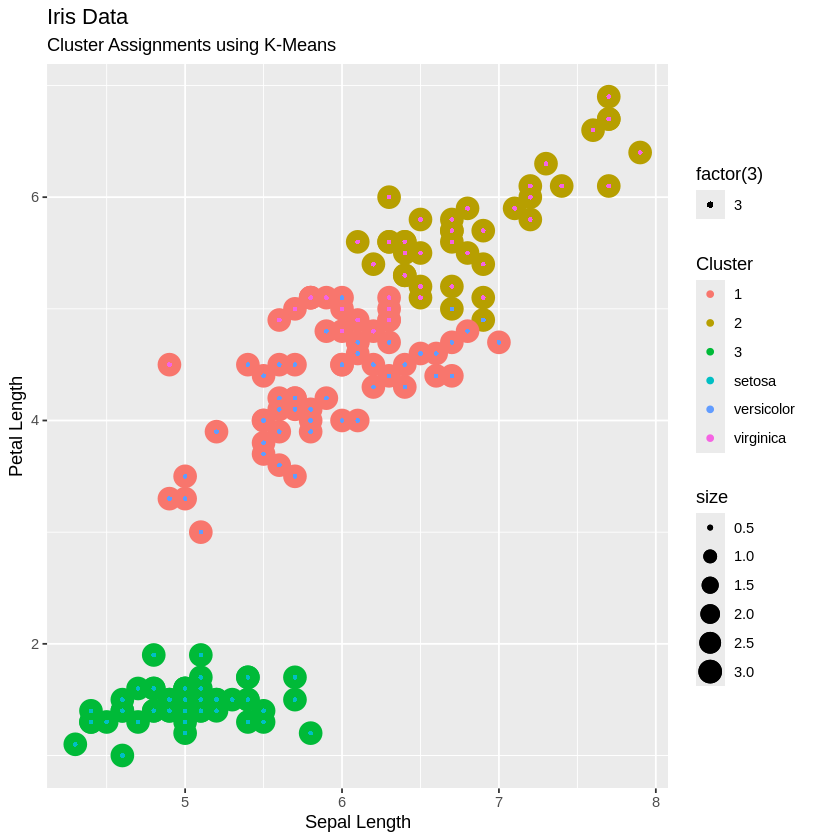

In [20]:
ggplot(iris.km) +
  ggtitle("Iris Data",
          subtitle="Cluster Assignments using K-Means") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color=Cluster,
                           size = 3)) +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color=Species,
                           size = 0.5,
                           shape = factor(3)))

Maybe not the worst idea, and we can see how the virginica species creeps into cluster 2 when it should be in cluster 3. But we can do better (I think), by simply using color and shape in a clever way.

Lets try species as color and cluster as SHAPE (this is why I made shape factor earlier)

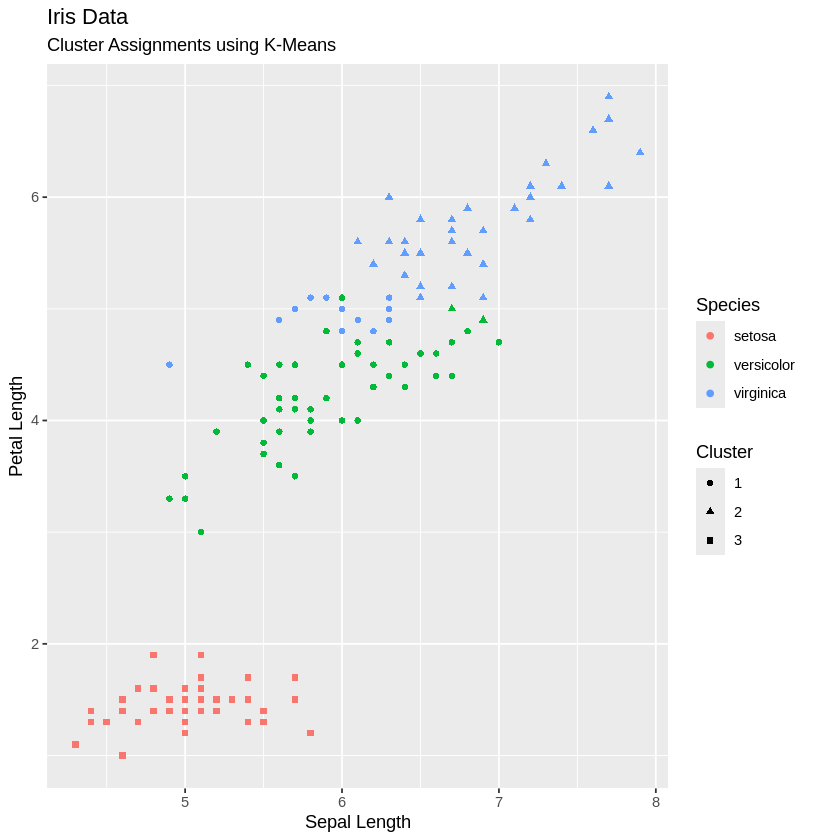

In [21]:
ggplot(iris.km) +
  ggtitle("Iris Data",
          subtitle="Cluster Assignments using K-Means") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

This is a nice plot! Or at least I like this plot - its a bit subjective, of course.

## **Plot from Lecture Notes**

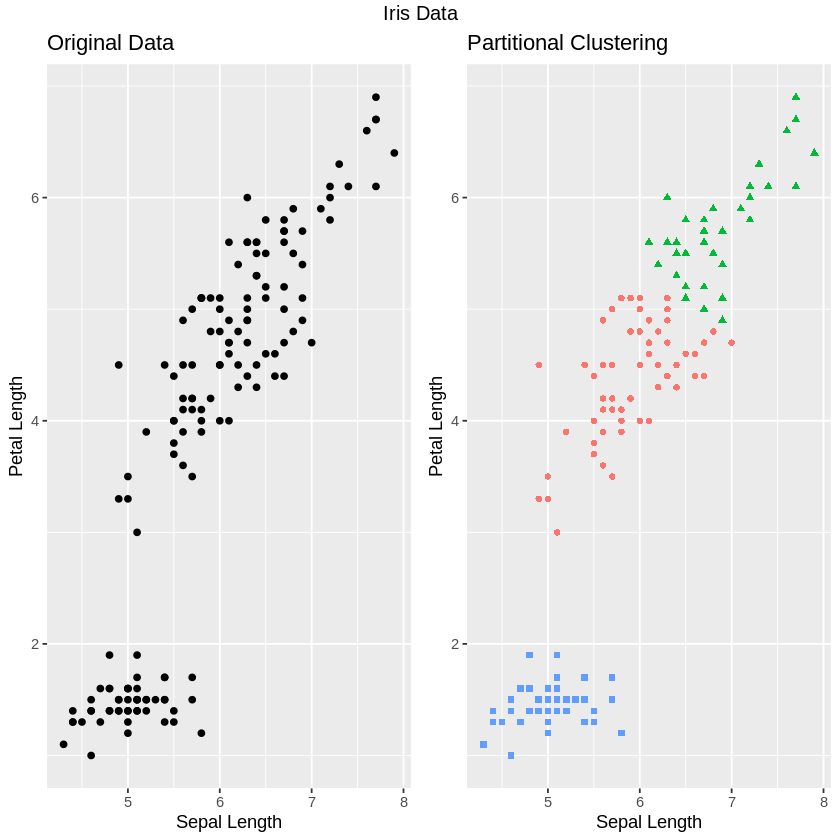

In [22]:
Iris.original = ggplot(iris.km) +
  ggtitle("Original Data") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length))
Iris.clustered = ggplot(iris.km) +
  ggtitle("Partitional Clustering") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Cluster,
                           shape = Cluster),
             show.legend = FALSE)

grid.arrange(Iris.original, Iris.clustered,
             ncol=2,
             top=textGrob("Iris Data"))

## **Convex Hull of Clusters**

We have visualized the three clusters, but we could also defined them (and add to the visualization) by finding the convex hull of the points in each cluster. The chull() function does the computation for us.

Pick out the data points corresponding to Cluster 1

In [23]:
data.1 = cbind(iris.km[which(iris.km$Cluster=="1"),]$Sepal.Length,
           iris.km[which(iris.km$Cluster=="1"),]$Petal.Length)

Find the convex hull of these data points using the chull() function

In [24]:
cluster.1 = chull(data.1)

Add the first data point to the end so that we can connect them

In [25]:
cluster.1 = c(cluster.1,cluster.1[1])

Put these into a data frame with the actual coordinates and the cluster assignment

In [26]:
cluster.1.df = data.frame(x=data.1[cluster.1,1],
                          y=data.1[cluster.1,2],
                          cluster = 1)

Repeat for Cluster 2 and Cluster 3

In [27]:
data.2 = cbind(iris.km[which(iris.km$Cluster=="2"),]$Sepal.Length,
               iris.km[which(iris.km$Cluster=="2"),]$Petal.Length)
cluster.2 = chull(data.2)
cluster.2 = c(cluster.2,cluster.2[1])
cluster.2.df = data.frame(x=data.2[cluster.2,1],
                          y=data.2[cluster.2,2],
                          cluster = 2)

data.3 = cbind(iris.km[which(iris.km$Cluster=="3"),]$Sepal.Length,
               iris.km[which(iris.km$Cluster=="3"),]$Petal.Length)
cluster.3 = chull(data.3)
cluster.3 = c(cluster.3,cluster.3[1])
cluster.3.df = data.frame(x=data.3[cluster.3,1],
                          y=data.3[cluster.3,2],
                          cluster = 3)

 Now we can add 3 layers to our plot - each corresponding to a different convex hull of a cluster.

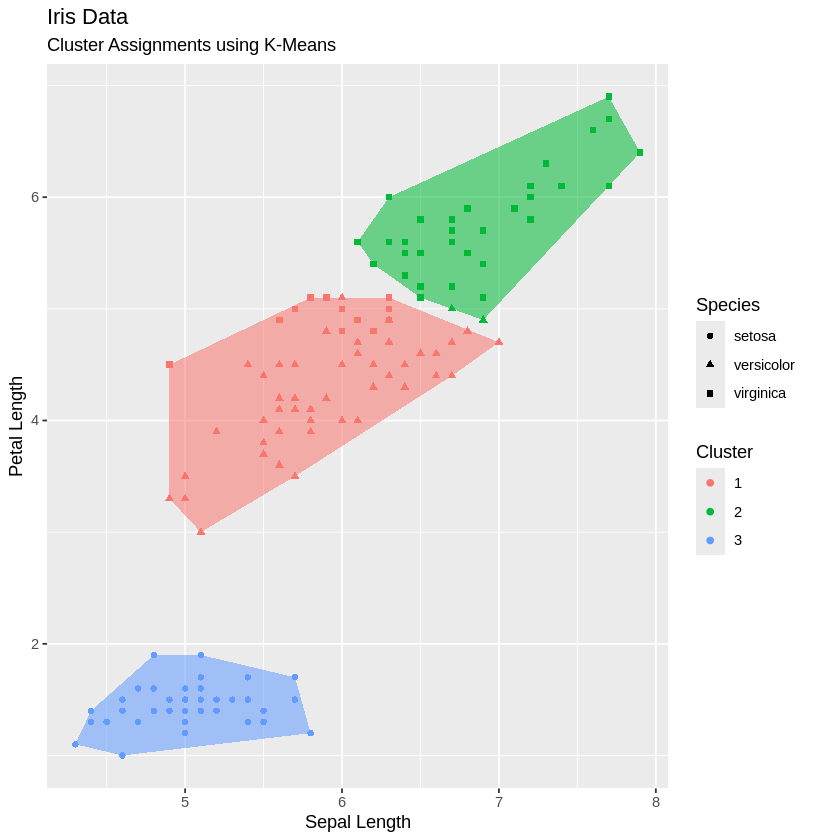

In [28]:
ggplot() +
  ggtitle("Iris Data",
          subtitle="Cluster Assignments using K-Means") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Cluster,     # Switched color/shape, so
                           shape = Species)) +  # color matches fill below
  geom_polygon(data = cluster.1.df, # This layer uses different data!
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.1),
               show.legend = FALSE) +
  geom_polygon(data = cluster.2.df,
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.1),
               show.legend = FALSE) +
  geom_polygon(data = cluster.3.df,
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.1),
               show.legend = FALSE)

If I don't like the default color schemes (and I don't), then I can change them by just adding two layers, one for fill and one for color. I can add these layers whereever I want in the sequence.

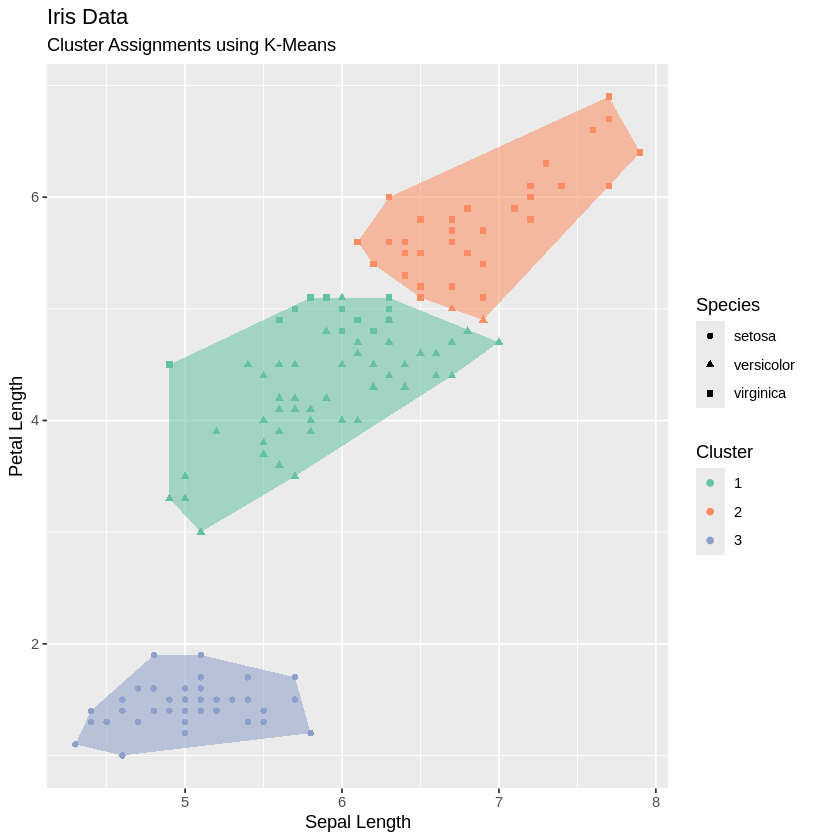

In [29]:
ggplot(iris.km) +
  scale_fill_brewer(palette="Set2") +   # Set the fill scale
  scale_color_brewer(palette="Set2") +  # Set the color scale
  ggtitle("Iris Data",
          subtitle="Cluster Assignments using K-Means") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Cluster,     # Switched color/shape, so
                           shape = Species)) +  # color matches fill below
  geom_polygon(data = cluster.1.df, # This layer uses different data!
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.5),
               show.legend = FALSE) +
  geom_polygon(data = cluster.2.df,
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.5),
               show.legend = FALSE) +
  geom_polygon(data = cluster.3.df,
               mapping = aes(x,y,
                             fill=as.factor(cluster),
                             alpha = 0.5),
               show.legend = FALSE)

For a full list of all the colorbrewer schemes see: https://colorbrewer2.org/#type=qualitative&scheme=Set2&n=3

And there are numerous other standard color schemes that you can use in ggplot.

An alternative to the filled polygons would be to just trace the path between the points in the convex hull using geom_path()

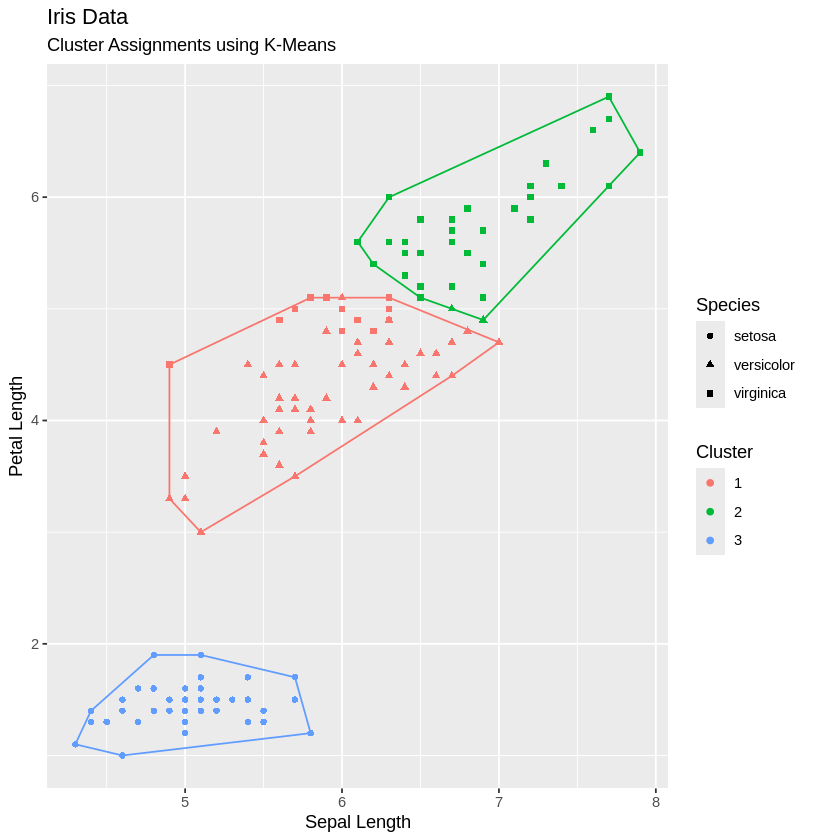

In [30]:
ggplot(iris.km) +
  ggtitle("Iris Data",
          subtitle="Cluster Assignments using K-Means") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.km,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Cluster,
                           shape = Species)) +
  geom_path(data = cluster.1.df,
               mapping = aes(x,y,
                             color=as.factor(cluster)),
               show.legend = FALSE) +
  geom_path(data = cluster.2.df,
               mapping = aes(x,y,
                             color=as.factor(cluster)),
               show.legend = FALSE) +
  geom_path(data = cluster.3.df,
               mapping = aes(x,y,
                             color=as.factor(cluster)),
               show.legend = FALSE)

Learning ggplot2 is very much worth your time.

Visualization and clustering go hand-in-hand. I know a cluster when I see it! But there are also quantitative performance measures for clustering, which we'll look at next.

Within sum-of-squared distance too center measures compactness

In [31]:
clusters.km$withinss

[1] 39.82097 23.87947 15.15100

Between SS measures distance between clusters

In [32]:
clusters.km$betweenss

[1] 602.5192

## **Hierarchical Clustering**

Now let's try hierarchical clustering (single- and complete-link)

R has a built-in hclust() function. Let's use it to apply single-link clustering. Again we only use the first four variables for our clustering.

In [33]:
clusters.sl <- hclust(dist(iris[,1:4]),method="single")

There is also a default method for plotting the dendrogram:

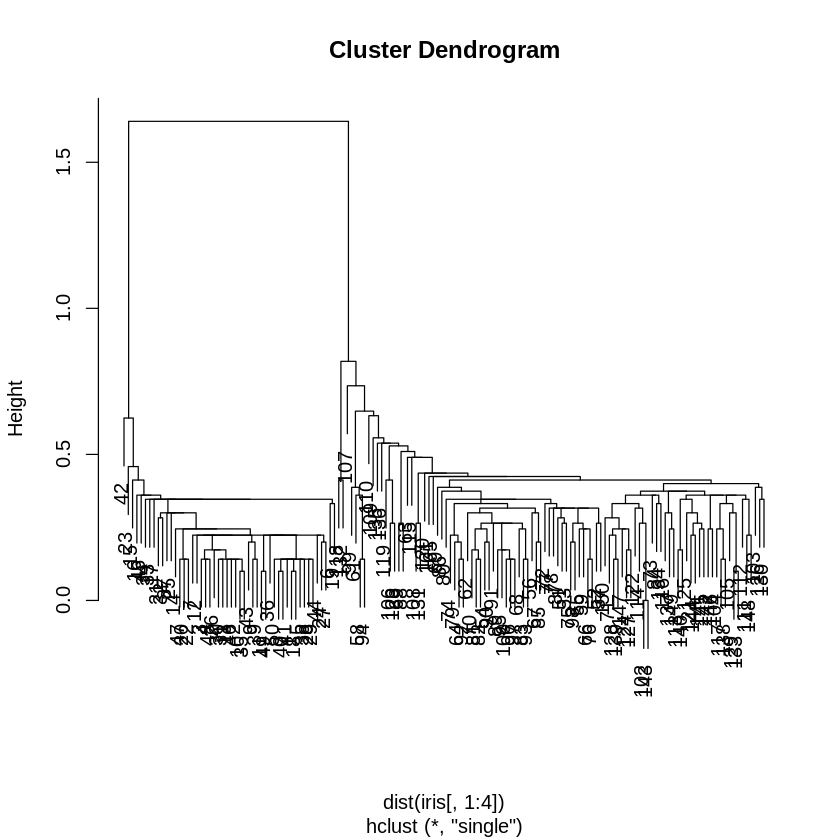

In [34]:
plot(clusters.sl)

But its not very good!

We can get the complete-link clustering by simply changing the method:

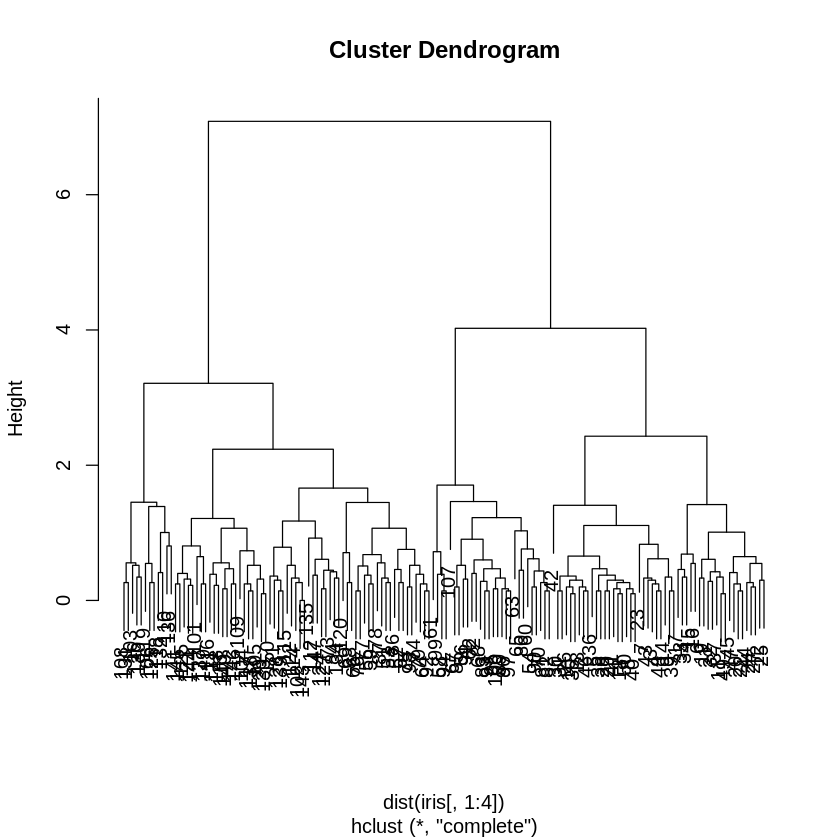

In [35]:
clusters.cl <- hclust(dist(iris[,1:4]),method="complete")
plot(clusters.cl)

Again the plot is poor, but we see expected differences.

## **Eclust: Visualize Cluster Assignments and Dendrogram**

The eclust function makes it easier to visualize clusters using the two primary principal components. It also allows us to call multiple clustering methods using one function (similar to train in caret).

Visualizing partitional clustering

In [36]:
clusters.km <- eclust(iris[,1:4], "kmeans",
                      k = 3, nstart = 25, graph = FALSE)

Here somebody already built a cluster vizualization function on top of ggplot, so we have to do much less work (but also have less flexibility to get exactly what we want):

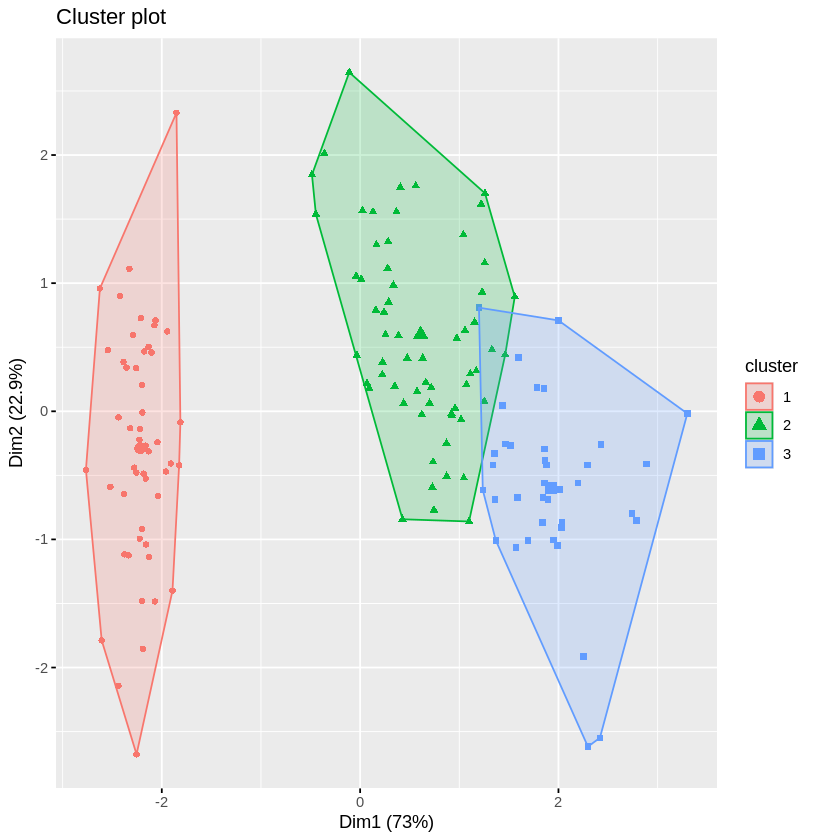

In [37]:
fviz_cluster(clusters.km,geom="point")

We see that they decided to use both shape and color to identify clusters + added a layer with the convex hull, similar to what we did above.

Furthermore, the x and y axis are not any of the original variables but rather the first two principal components (will discuss soon).

Essentially the principal components are constructed to to explain as much of the variability as possible. Here the first component explains 73% of the variability, the second 22.9%, and the third 3.7% of the variability.

The principal components are VERY useful for visualization, and we can choose here to use different components, e.g.,

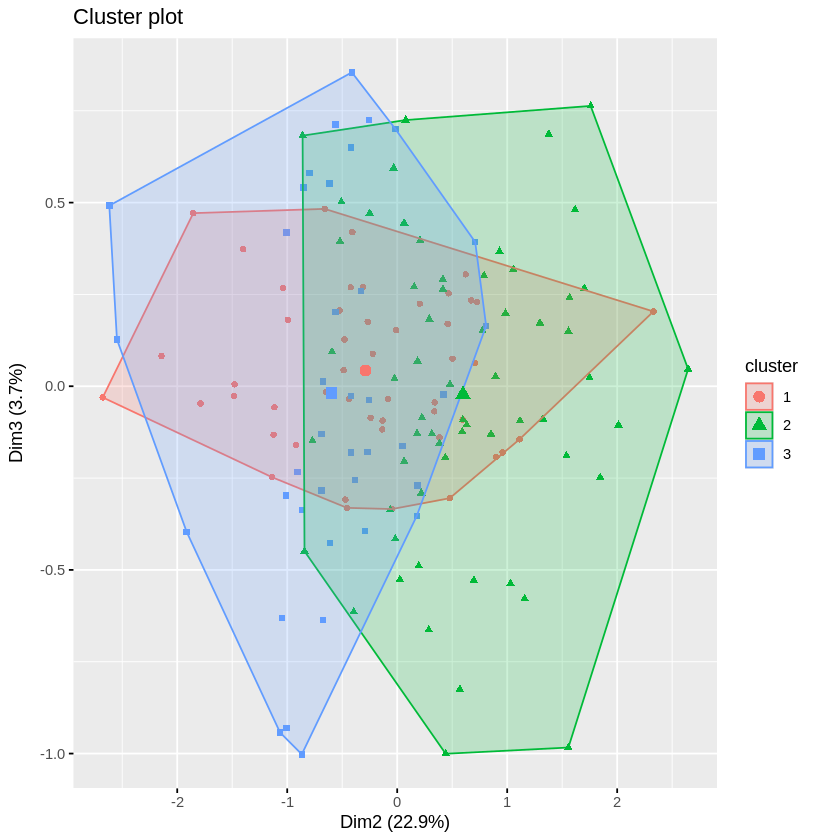

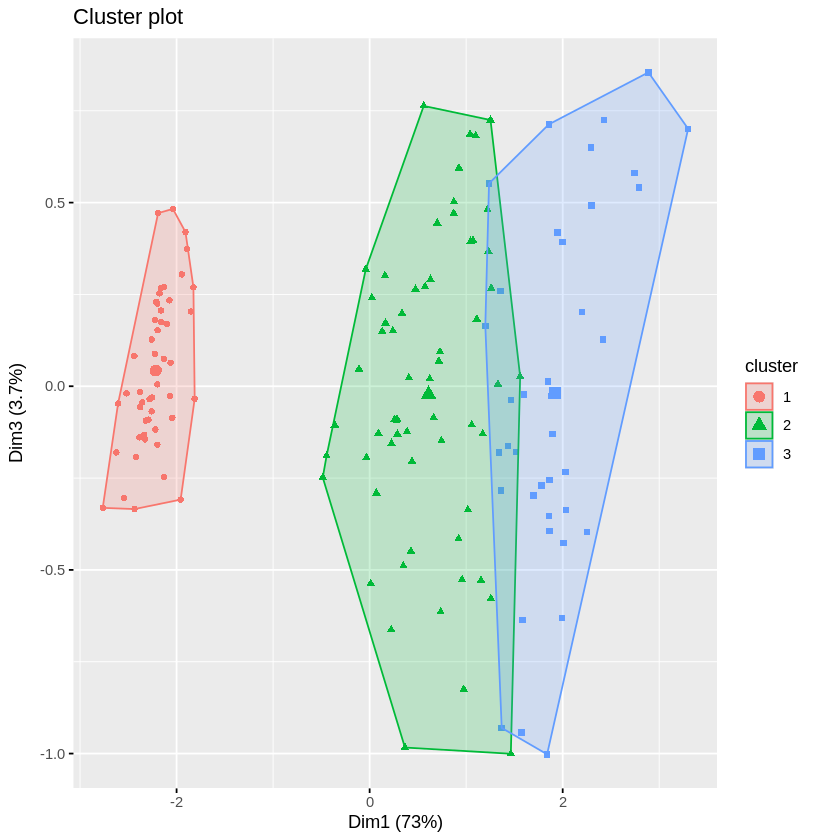

In [38]:
fviz_cluster(clusters.km,geom="point",
             axes=c(2,3))
fviz_cluster(clusters.km,geom="point",
             axes=c(1,3))

Here the 1st and 2nd principal components look the most useful, which is not surprising since together they explain 73+22.9 = 95.9% of the variability in the data.

This is not always the case. I'll show you an example later in the semester where a plot of the second and third principal components turns out to be the most insightful.

The upside to using a function like fviz_cluster() is speed.We needed a lot more work to create our own. The downside is inability to really tailor things to your data and your  application. Here, for example, we have the special variable of interest: species. The best visualization will have species and the clusters on the same plot and fviz_cluster() will not do that for us.

You can also use eclust to create hierarchical clustering, and visualize them as a dendrogram:

In [ ]:
clusters.cl <- eclust(iris[,1:4], "hclust", k = 3,
                      hc_method="complete", graph = FALSE)
fviz_dend(clusters.cl,show_labels = FALSE, rect=TRUE)

Looks much better than the default dendrogram and it would be pretty difficult to do the from scratch.

## **Cluster Validation**

In a above analysis we (correctly) assumed that there were 3 clusters.

In practice this is usually unknown but we can use cluster validation to determine the number of clusters

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


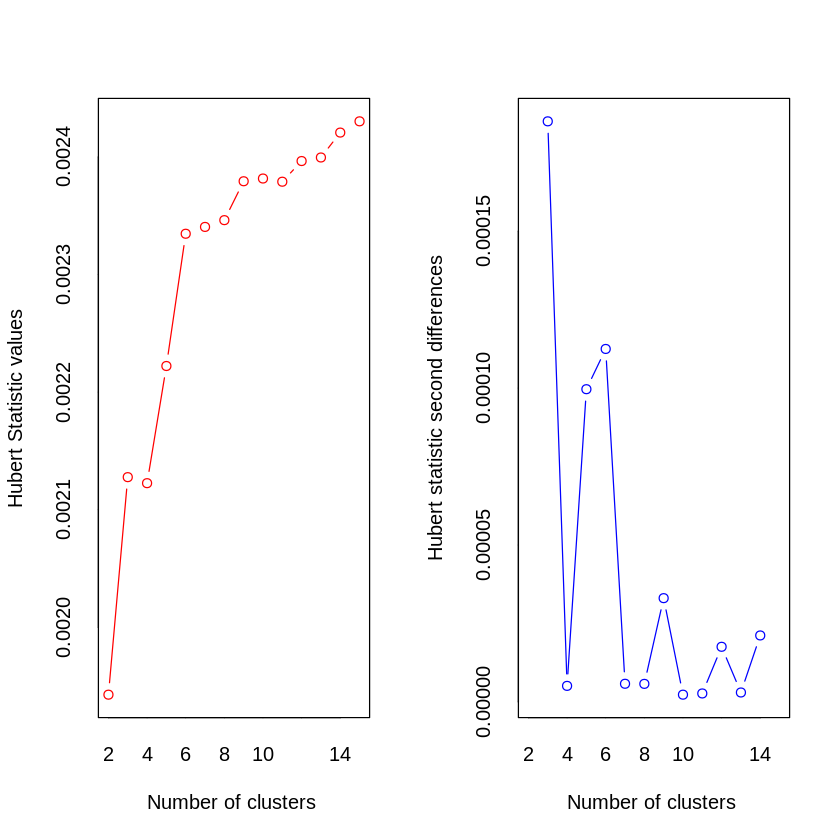

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 9 proposed 2 as the best number of clusters 
* 10 proposed 3 as the best number of clusters 
* 3 proposed 6 as the best number of clusters 
* 1 proposed 10 as the best number of clusters 
* 1 proposed 15 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  3 
 
 
******************************************************************* 


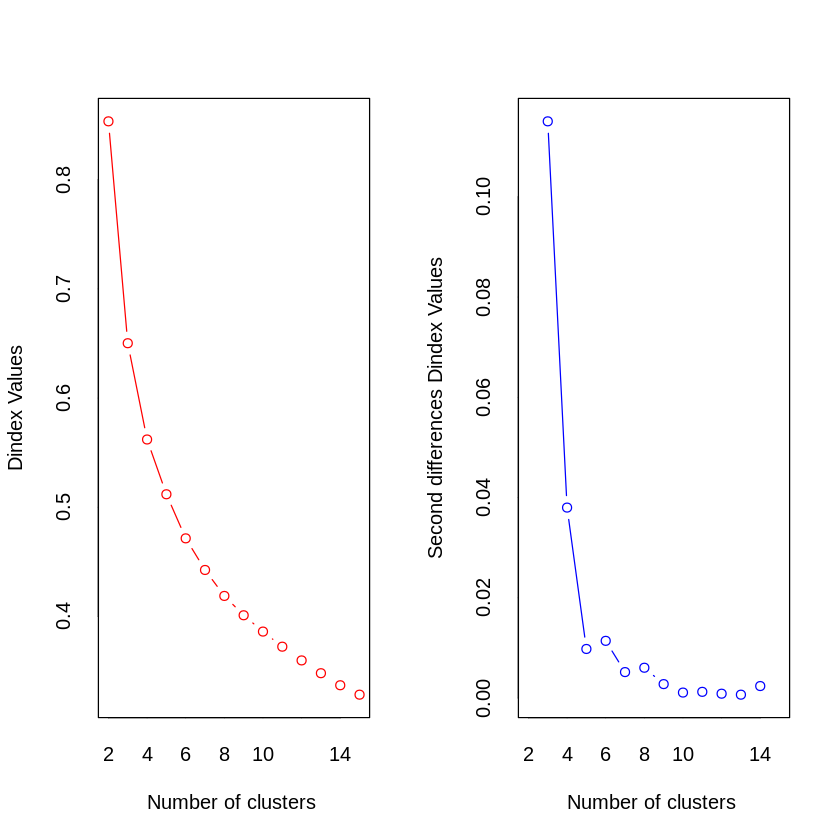

In [39]:
valClust = NbClust(data=iris[,1:4],
                   method = "ward.D", # Clustering method
                                      # (hierarchical)
                   index = "all")     # Validation methods
                                      # considered

10 indices proposed 3 as the best number of clusters (correct) 9 proposed 2 (incorrect, but easy confusion to make) 5 proposed another value (6,10,15)

So majority rule is correct, but still it is not unanimous, even for a very, very simple dataset!

What NbClus is actually doing is using different clustering methods to obtain a clustering, and then evaluating the quality based on different quality meaasures (here called index). Try another clustering method by changing to "method = "single". Results are very different!

In [40]:
valClust$Best.nc

,KL,CH,Hartigan,CCC,Scott,Marriot,TrCovW,TraceW,Friedman,Rubin,⋯,Ratkowsky,Ball,PtBiserial,Frey,McClain,Dunn,Hubert,SDindex,Dindex,SDbw
Number_clusters,2.00,3.0000,3.0000,3.0000,3.0000,3.00,3.0000,3.0000,10.0000,3.0000,⋯,2.0000,3.0000,2.0000,3.0000,2.0000,2.0000,0,2.0000,0,15.0000
Value_Index,5.67,556.8795,89.1486,37.5635,161.5737,60382.84,693.1892,54.8885,185.1921,-16.4384,⋯,0.5535,50.9917,0.8358,1.7752,0.2622,0.3389,0,1.4034,0,0.0229


Let's try single-link and just one quality measure (Hartigan) that we know only looks at compactness.

In [41]:
valClust = NbClust(data=iris[,1:4],
                   method = "single",
                   index = "hart")

We can output the best number of clusters when we use single-link clustering and the Hartigan index to evaluate the different results

In [42]:
valClust$Best.nc

Number_clusters     Value_Index 
        11.0000         23.9509

Not surprisingly, the "single-link" and "hart" combination, results in a large number of clusters (k=11)!

The actual assignment of clusters to instances is stored, so we can take a look:

In [43]:
valClust$Best.partition

[1]  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 [26]  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  1  1  1  1  1  1  1  1
 [51]  3  3  3  3  3  3  3  4  3  3  4  3  3  3  3  3  3  3  3  3  3  3  3  3  3
 [76]  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  4  3  3  3  3  4  3
[101]  3  3  3  3  3  5  6  3  7  8  3  3  3  3  3  3  3  9  5  3  3  3  5  3  3
[126]  3  3  3  3  3  3  9  3  3 10 11  3  3  3  3  3  3  3  3  3  3  3  3  3  3

What the best single-link set of clusters (according to Hartigan) looks like is two large clusters and many clusters that may only contain one instance!

Experiment with different methods and indices

Also note that it's possible to change the default minimum and maximum number of clusters that are tried (default 2-15)

##**Silhouette Plots**

  cluster size ave.sil.width
1       1   50          0.80
2       2   62          0.42
3       3   38          0.45
  cluster size ave.sil.width
1       1   50          0.80
2       2   62          0.42
3       3   38          0.45


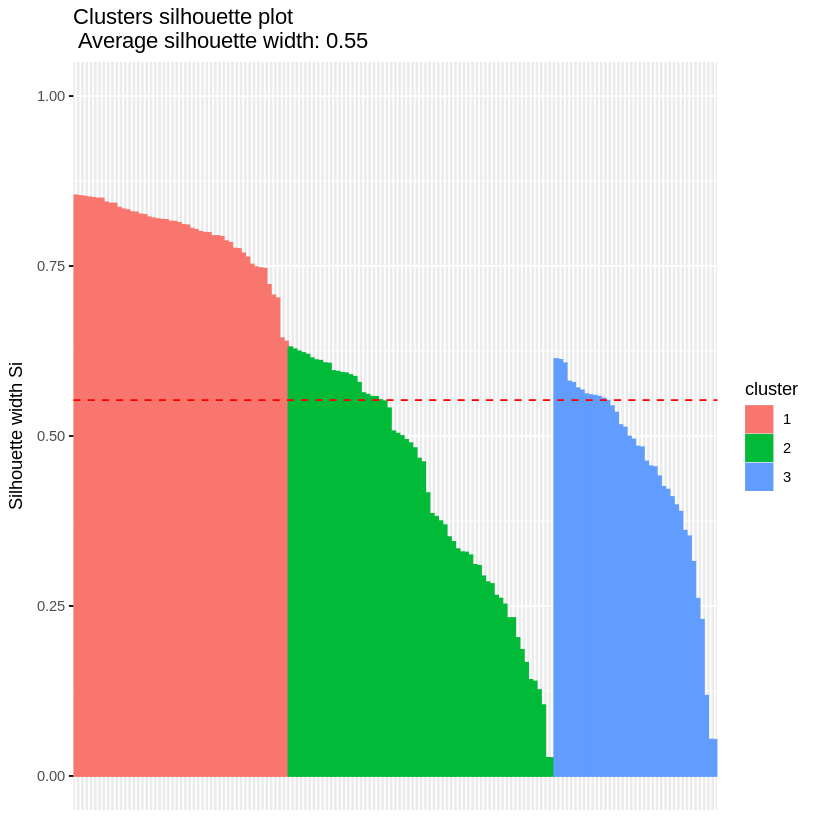

  cluster size ave.sil.width
1       1   11          0.31
2       2   16          0.24
3       3   12          0.34
4       4   23          0.25
5       5   39          0.28
6       6   24          0.42
7       7   25          0.42


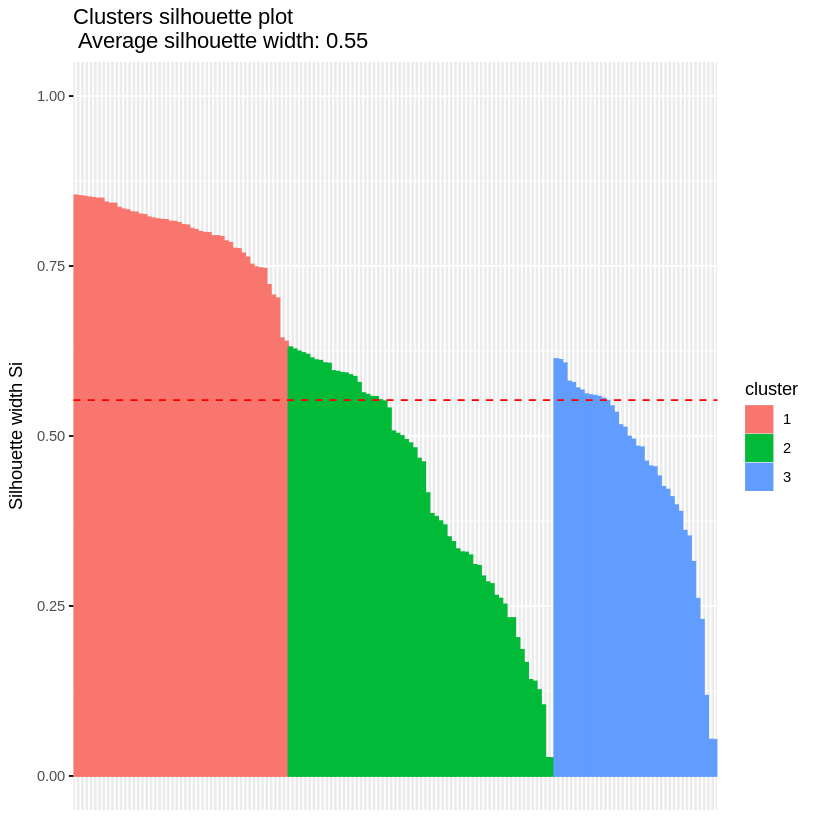

  cluster size ave.sil.width
1       1   11          0.31
2       2   16          0.24
3       3   12          0.34
4       4   23          0.25
5       5   39          0.28
6       6   24          0.42
7       7   25          0.42


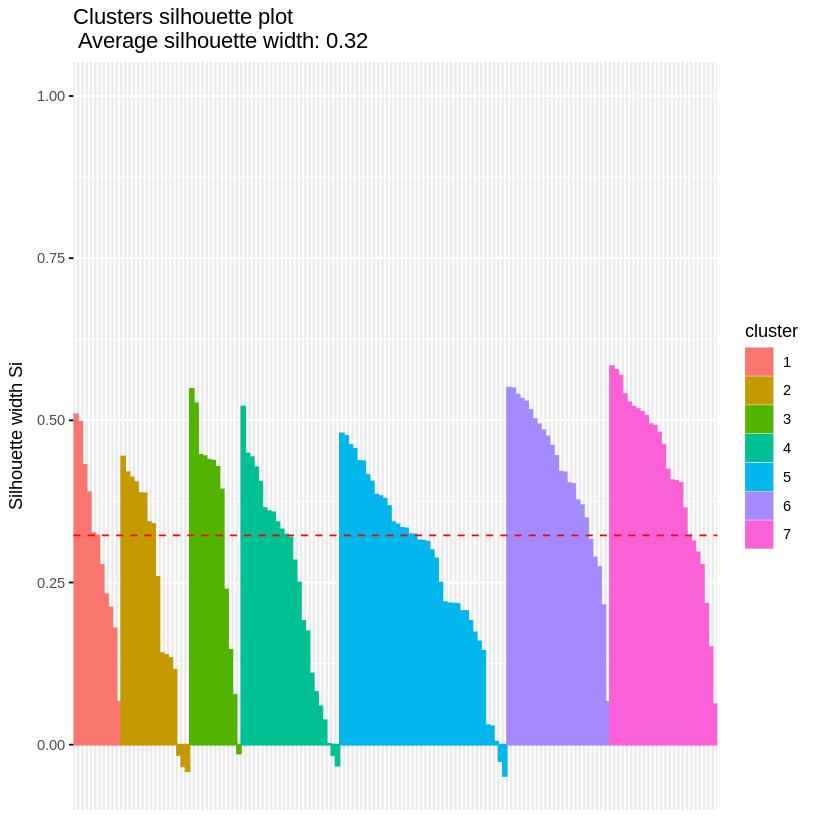

  cluster size ave.sil.width
1       1   11          0.31
2       2   16          0.24
3       3   12          0.34
4       4   23          0.25
5       5   39          0.28
6       6   24          0.42
7       7   25          0.42


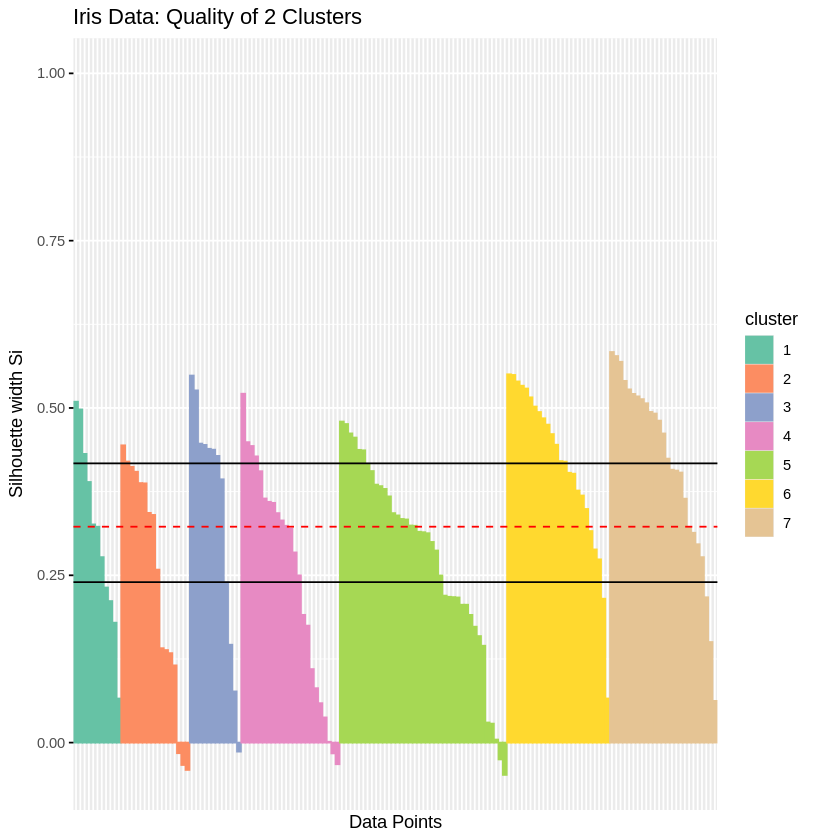

  cluster size ave.sil.width
1       1   11          0.31
2       2   16          0.24
3       3   12          0.34
4       4   23          0.25
5       5   39          0.28
6       6   24          0.42
7       7   25          0.42


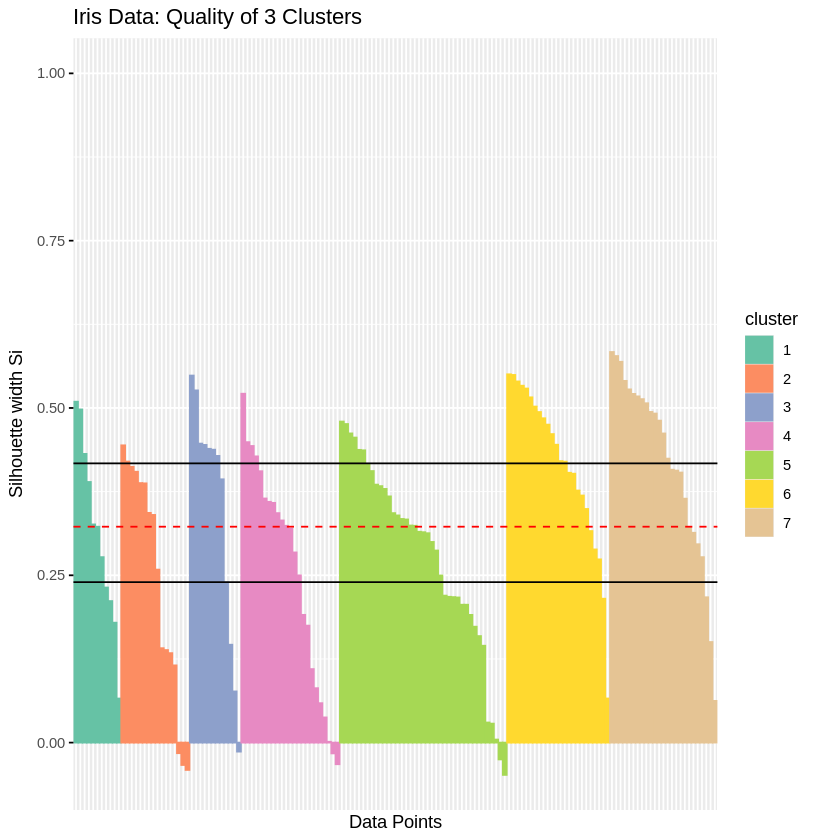

  cluster size ave.sil.width
1       1   11          0.31
2       2   16          0.24
3       3   12          0.34
4       4   23          0.25
5       5   39          0.28
6       6   24          0.42
7       7   25          0.42


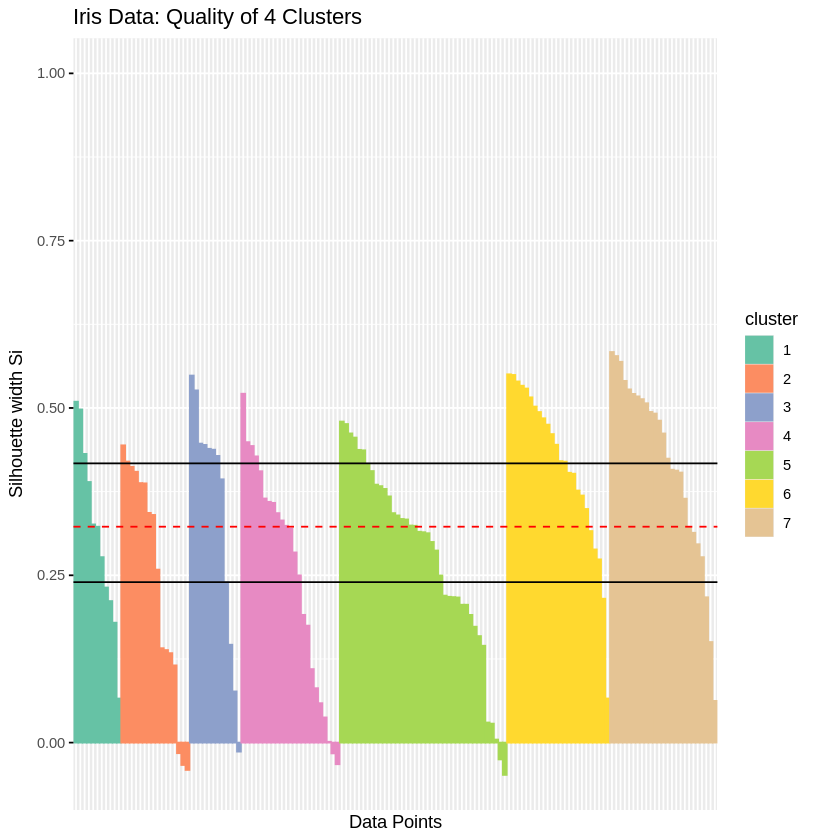

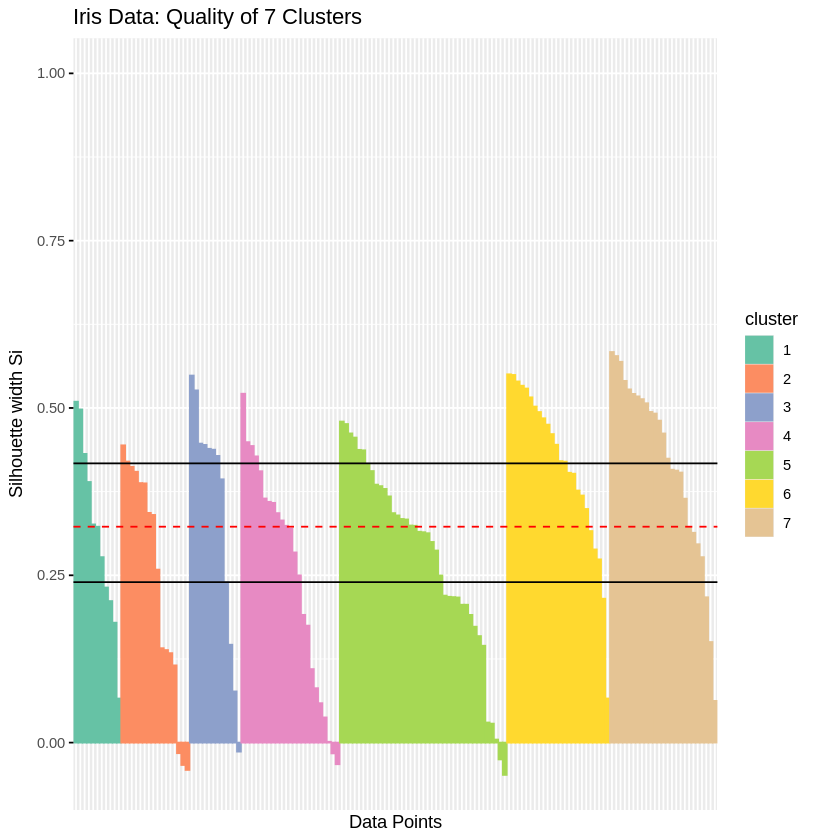

In [47]:
Clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 2, graph = FALSE)

fviz_silhouette (clusters.km)

clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 3, graph = FALSE)

fviz_silhouette (clusters.km)

clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 7, graph = FALSE)

fviz_silhouette (clusters.km)

#Since these are gig-lot objects, I can add and change layers if I want

Clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 2, graph = FALSE)

fviz_silhouette (clusters.km) +
	scale_color_brewer (palette = "Set2") +
	scale_fill_brewer (palette = "Set2") +
	ggtitle ("Iris Data: Quality of 2 Clusters") +
	xlab ("Data Points") +
	geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
	geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

Clusters.km <- eclust (iris[,1:4], "kmeans",
                        k =3, graph = FALSE)

fviz_silhouette (clusters.km) +
	scale_color_brewer (palette = "Set2") +
	scale_fill_brewer (palette = "Set2") +
	ggtitle ("Iris Data: Quality of 3 Clusters") +
	xlab ("Data Points") +
	geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
	geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

Clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 4, graph = FALSE)

fviz_silhouette (clusters.km) +
	scale_color_brewer (palette = "Set2") +
	scale_fill_brewer (palette = "Set2") +
	ggtitle ("Iris Data: Quality of 4 Clusters") +
	xlab ("Data Points") +
	geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
	geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

Clusters.km <- eclust (iris[,1:4], "kmeans",
                        k = 7, graph = FALSE)

fviz_silhouette (clusters.km) +
	scale_color_brewer (palette = "Set2") +
	scale_fill_brewer (palette = "Set2") +
	ggtitle ("Iris Data: Quality of 7 Clusters") +
	xlab ("Data Points") +
	geom_hline (yintercept=min(clusters.km$silinfo$clus.avg.widths))+
	geom_hline (yintercept=max(clusters.km$silinfo$clus.avg.widths))

## **DBSCAN**

In [60]:
dbscan(iris[,1:4],
       eps = 0.01) # The eps parameter has no default!
dbscan(iris[,1:4],
       eps = 0.1)
# If we set eps = 0.01 or eps = 0.1, it find all noise

dbscan(iris[,1:4],
       eps = 1)
# If we set eps = 1 we find two clusters. This is
# quite reasonable.

dbscan(iris[,1:4],
       eps = 2)
# If we set eps = 2 we put everything in one cluster!

# The success of dbscan really depends on being able to
# set a a reasonable eps value, that is, find a uniform
# scale for the density.

# Best results so far:
db.clusters = dbscan(iris[,1:4],
       eps = 1)
db.clusters$cluster

# The package has a function that helps us find a value
# for epsilon
kNNdistplot(iris[,1:4])
# From this, I would say that eps = 0.6 is good
db.clusters.2 = dbscan(iris[,1:4],
                       eps = 0.6)
iris.db = cbind(iris, db.clusters.2$cluster)
colnames(iris.db)[6]="Cluster"
iris.db$Cluster = as.factor(iris.db$Cluster)
DB2 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.6)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

DBSCAN clustering for 150 objects.
Parameters: eps = 0.01, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 0 cluster(s) and 150 noise points.

  0 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 0.1, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 0 cluster(s) and 150 noise points.

  0 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 1, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 2 cluster(s) and 0 noise points.

  1   2 
 50 100 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 2, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 1 cluster(s) and 0 noise points.

  1 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 [75] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[112] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[149] 2 2

ERROR: Error in kNNdistplot(iris[, 1:4]): k or minPts need to be specified.


DBSCAN clustering for 150 objects.
Parameters: eps = 0.01, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 0 cluster(s) and 150 noise points.

  0 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 0.1, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 0 cluster(s) and 150 noise points.

  0 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 1, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 2 cluster(s) and 0 noise points.

  1   2 
 50 100 

Available fields: cluster, eps, minPts, metric, borderPoints

DBSCAN clustering for 150 objects.
Parameters: eps = 2, minPts = 5
Using euclidean distances and borderpoints = TRUE
The clustering contains 1 cluster(s) and 0 noise points.

  1 
150 

Available fields: cluster, eps, minPts, metric, borderPoints

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2
 [75] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 0 2
[112] 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[149] 2 2

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
1,5.1,3.5,1.4,0.2,setosa,1
2,4.9,3.0,1.4,0.2,setosa,1
3,4.7,3.2,1.3,0.2,setosa,1
4,4.6,3.1,1.5,0.2,setosa,1
5,5.0,3.6,1.4,0.2,setosa,1
6,5.4,3.9,1.7,0.4,setosa,1



 0  1  2 
 9 49 92 

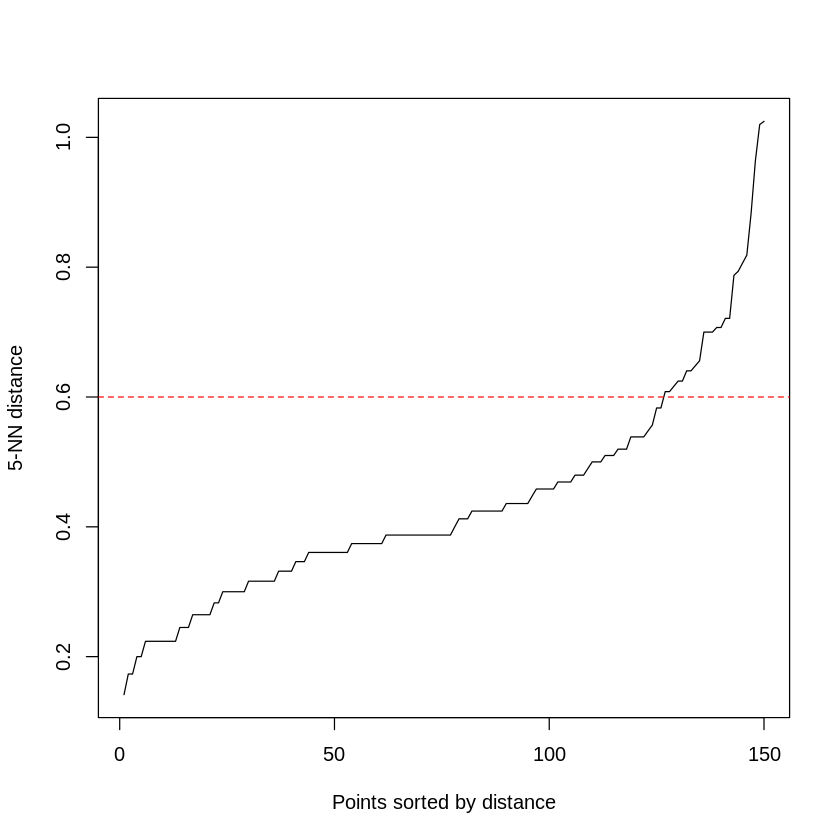

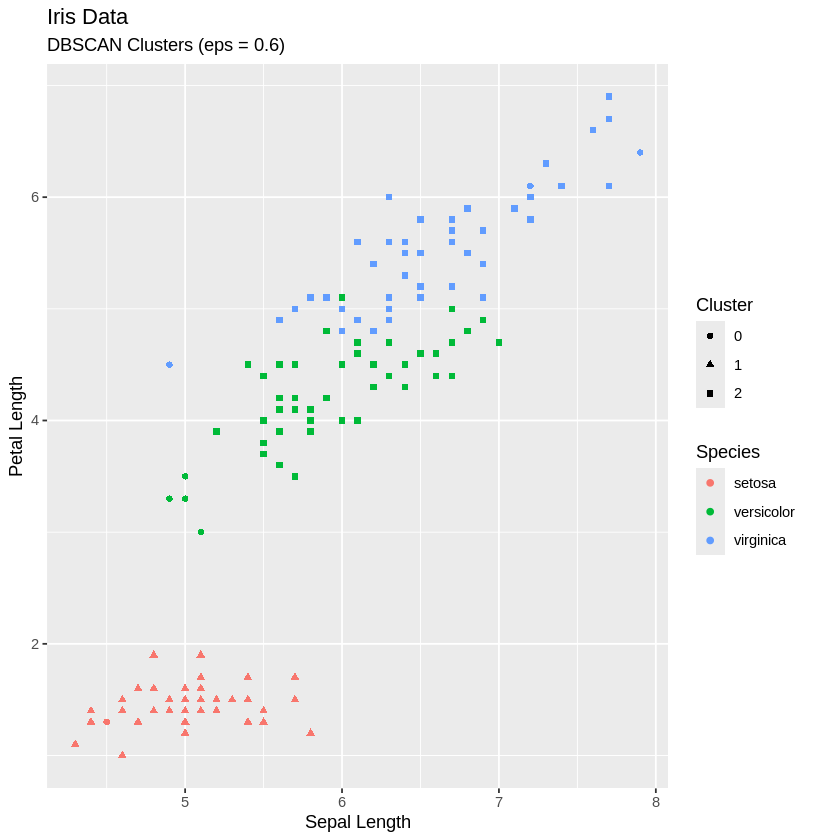

In [63]:

# ---------------------------------------------------------
# 1. Try DBSCAN with different eps values
# ---------------------------------------------------------

dbscan(iris[,1:4], eps = 0.01, minPts = 5)
dbscan(iris[,1:4], eps = 0.1, minPts = 5)
dbscan(iris[,1:4], eps = 1,   minPts = 5)
dbscan(iris[,1:4], eps = 2,   minPts = 5)

# ---------------------------------------------------------
# 2. Use kNNdistplot to find a good eps value
#    IMPORTANT: must specify k or minPts
# ---------------------------------------------------------

kNNdistplot(iris[,1:4], k = 5)
abline(h = 0.6, col = "red", lty = 2)   # optional visual guide

# ---------------------------------------------------------
# 3. Run DBSCAN with chosen eps
# ---------------------------------------------------------

db.clusters <- dbscan(iris[,1:4], eps = 0.6, minPts = 5)

# Inspect cluster assignments
db.clusters$cluster

# ---------------------------------------------------------
# 4. Add cluster labels to the iris dataset
# ---------------------------------------------------------

iris.db <- data.frame(iris, Cluster = as.factor(db.clusters$cluster))

# Inspect the new dataset
head(iris.db)
table(iris.db$Cluster)

DB2 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.6)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

DB2


Cluster 0 really doesn't make a lot of sense, but it is non-setosa iris that has either very short or very long sepal length. We can get a little more insight by plotting sepal length and petal length, where we see that is consists of either very short sepal length or very long petal length. So DBSCAN is doing SOMETHING, it may just not be very good.

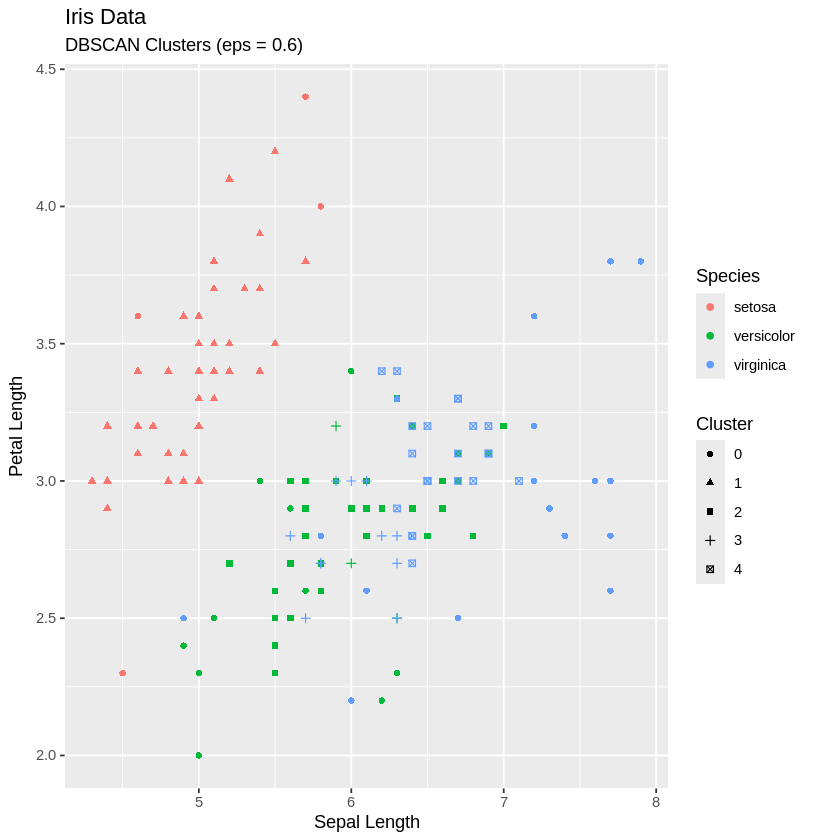

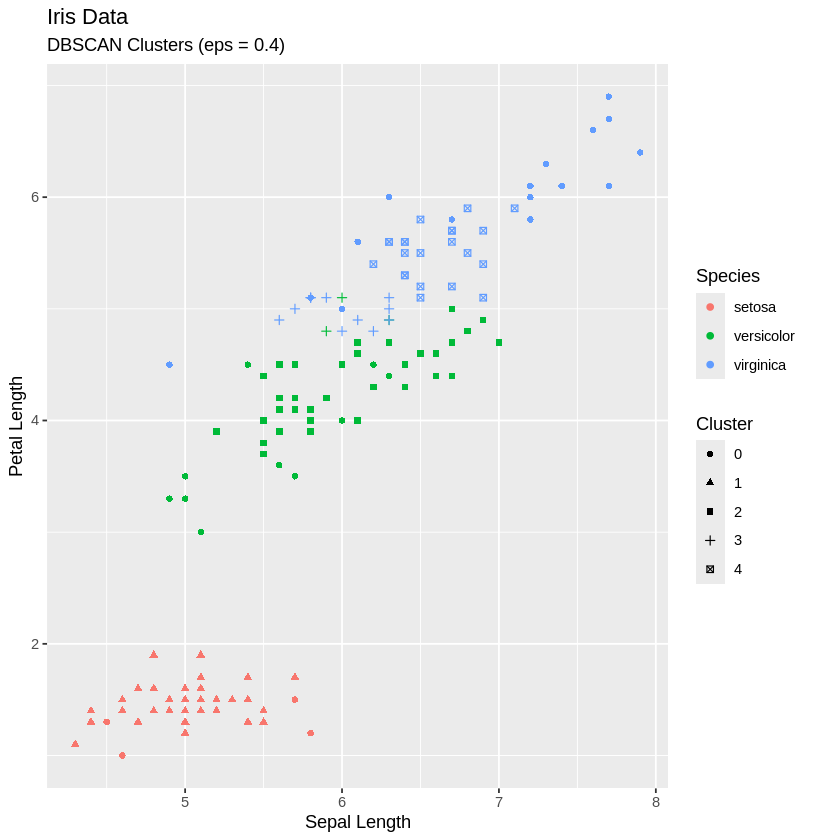

In [65]:
ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.6)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Sepal.Width,
                           color = Species,
                           shape = Cluster))

# The results are quite sensitive to  the exact value
# of epsilon. If we set is a little smaller we get a
# whole lot of clusters!
db.clusters.3 = dbscan(iris[,1:4],
                       eps = 0.4)
iris.db = cbind(iris, db.clusters.3$cluster)
colnames(iris.db)[6]="Cluster"
iris.db$Cluster = as.factor(iris.db$Cluster)
DB3 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.4)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))
DB3

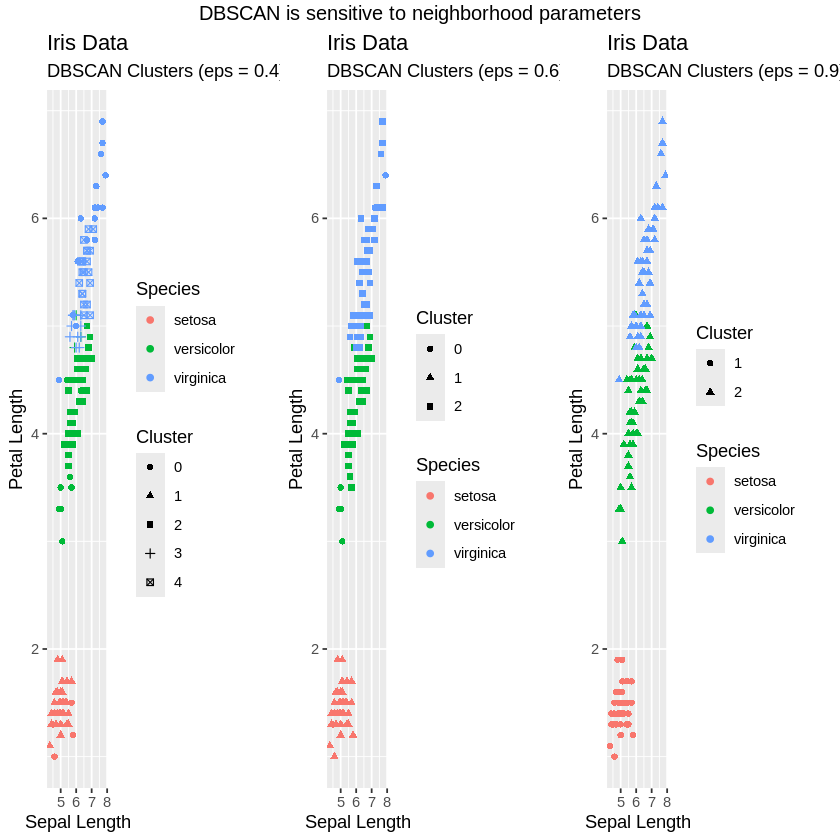

In [66]:
# Re-create DB2 as it might not be in scope
db.clusters.2 = dbscan(iris[,1:4],
                       eps = 0.6)
iris.db = cbind(iris, db.clusters.2$cluster)
colnames(iris.db)[6]="Cluster"
iris.db$Cluster = as.factor(iris.db$Cluster)
DB2 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.6)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

# Re-create DB3 as it might not be in scope
db.clusters.3 = dbscan(iris[,1:4],
                       eps = 0.4)
iris.db = cbind(iris, db.clusters.3$cluster)
colnames(iris.db)[6]="Cluster"
iris.db$Cluster = as.factor(iris.db$Cluster)
DB3 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.4)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

# If we set epsilon a little higher, we get only
# two clusters.
db.clusters.4 = dbscan(iris[,1:4],
                       eps = 0.9)
iris.db = cbind(iris, db.clusters.4$cluster)
colnames(iris.db)[6]="Cluster"
iris.db$Cluster = as.factor(iris.db$Cluster)
DB4 = ggplot(iris.db) +
  ggtitle("Iris Data",
          subtitle="DBSCAN Clusters (eps = 0.9)") +
  xlab("Sepal Length") +
  ylab("Petal Length") +
  geom_point(data = iris.db,
             mapping = aes(Sepal.Length,
                           Petal.Length,
                           color = Species,
                           shape = Cluster))

# Plot from lecture notes
grid.arrange(DB3, DB2, DB4,
             ncol=3,
             top=textGrob("DBSCAN is sensitive to neighborhood parameters"))